In [2]:
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf,sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, subcarrier_frequencies, RadioMapSolver
scene = load_scene(sionna.rt.scene.etoile)
# Configure arrays for all transmitters and receivers in the scene
# Add a transmitter and a receiver
scene.remove("tx")
scene.remove("rx")

scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="tr38901", polarization="V")
##############################################################################
# Replace the planar Rx array by a 1×64 ULA   (64 elements, 0.5 λ spacing)
##############################################################################
# N_ula = 64
# scene.rx_array = PlanarArray(num_rows=1,          # ONE row
#                              num_cols=N_ula,      # many columns
#                              vertical_spacing=0.5,  # ignored (only 1 row)
#                              horizontal_spacing=0.5, # 0.5 λ (default units = λ)
#                              pattern="tr38901",
#                              polarization="V")
scene.rx_array = PlanarArray(
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",  # or "iso"
    polarization="V")
# Tx can stay planar or point source; only Rx matters for AoA extraction

scene.add(Transmitter("tx", [-25,0.1,50]))
scene.add(Receiver("rx",    [ 25,0.1,50]))


# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene, max_depth=5,
                       los=True,
                       specular_reflection=True,
                       diffuse_reflection=False,
                       refraction=False,
                       synthetic_array=False
                       )

num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False, normalize_delays=False,
                   out_type='numpy')         # shape (1, 64, 1, 1, 1, 1024)

print("Shape of channel frequency response: ", h_freq.shape) 

Delay   resolution (ns):  32
Doppler resolution (Hz):  29
Shape of channel frequency response:  (1, 64, 1, 1, 1, 1024)


H.shape = (64, 1024)
Shape of CIR:  (1, 64, 1, 1, 6, 1)
Shape of CIR:  (1, 1, 6)
 Path #  Delay (ns)  Azimuth (deg)  Zenith (deg)  Power (dB rel)
      0  166.800003     180.000000     90.000000        0.000000
      1  372.899994     180.000000    153.399994      -27.400000
      2 2269.000000     -44.799999     98.500000      -44.299999
      3 1572.599976     -83.500000     98.300003      -54.500000
      4  864.799988     160.100006    112.699997      -84.400002
      5 1657.599976     173.399994    101.599998      -56.900002
[!] Path 0: AoA -180.0° 超出 ULA 的解析範圍，跳過
[!] Path 1: AoA -180.0° 超出 ULA 的解析範圍，跳過
[!] Path 4: AoA 160.1° 超出 ULA 的解析範圍，跳過
[!] Path 5: AoA 173.4° 超出 ULA 的解析範圍，跳過


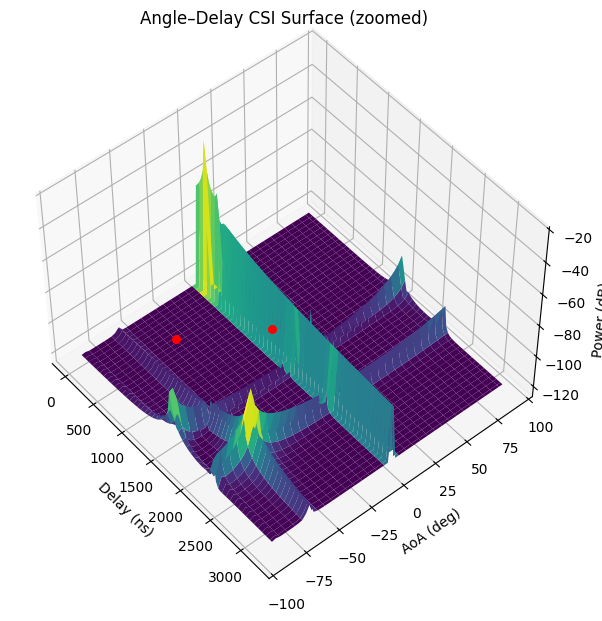

In [28]:
# ---------------------------------------------------------------------
# Step 1: squeeze 並重新排列維度  → shape: (num_rx_ant=64, num_subcarriers=1024)
# ---------------------------------------------------------------------
H = h_freq[0,:,0,0,0,:]      # shape: (64, 1024)
print("H.shape =", H.shape)

# ---------------------------------------------------------------------
# Step 2: 空間 FFT (天線 → 角度)     ← axis=0
# ---------------------------------------------------------------------
H_shifted = np.fft.fftshift(H, axes=0)         # 天線軸居中
H_ang     = np.fft.fft(H_shifted, axis=0)      # 空域 FFT
H_ang     = np.fft.ifftshift(H_ang, axes=0)    # 移回來，便於畫圖

# ---------------------------------------------------------------------
# Step 3: 頻率 IFFT (subcarriers → delay) ← axis=1
# ---------------------------------------------------------------------
h_delay = np.fft.ifft(H_ang, axis=1, norm="ortho")   # shape: (64 angle, 1024 delay)

# ---------------------------------------------------------------------
# Step 4: 建立 AoA + Delay 的 X/Y 軸資料
# ---------------------------------------------------------------------
num_angles = H.shape[0]     # =64
num_delays = H.shape[1]     # =1024

# AoA 座標軸：-90° ～ +90°
angles = np.linspace(-90, 90, num_angles)

# Delay 座標軸：依據子載波解析度
delays = np.arange(0, num_delays * delay_resolution, delay_resolution) / 1e-9  # ns

X, Y = np.meshgrid(delays, angles)     # delay → x, AoA → y
# --- 轉 dB scale + 限制 delay 軸範圍 ---
Z = 10 * np.log10(np.abs(h_delay)**2 + 1e-12)


delay_cut = 100   # ← 可調整
X_cut = X[:, :delay_cut]
Y_cut = Y[:, :delay_cut]
Z_cut = Z[:, :delay_cut]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

import numpy as np, pandas as pd
a, tau = paths.cir(normalize_delays=False, out_type="numpy")
print("Shape of CIR: ", a.shape) # shape (1, 1, 1, 1, 64, 1024)
print("Shape of CIR: ", tau.shape) # shape (1, 1, 1, 1, 64, 1024)
a_sel      = a  [0, 0, 0, 0, :, 0]
tau_ns     = tau[0, 0, :] / 1e-9
Zenith_deg    = np.degrees(paths.theta_r.numpy()[0,0,:])#Zenith angles of arrival [rad]
phi_deg    = np.degrees(paths.phi_r.numpy()[0,0,:]) #Azimuth angles of arrival
pow_lin    = np.abs(a_sel)**2
# ---- pull the six paths for Rx ant 0, Tx ant 0 ----


pow_lin = np.abs(a_sel)**2
pow_db  = 10*np.log10(pow_lin + 1e-30)

tbl = pd.DataFrame({
        'Path #': np.arange(len(a_sel)),
        'Delay (ns)': np.round(tau_ns,   1),
        'Azimuth (deg)': np.round(phi_deg,1),
        'Zenith (deg)': np.round(Zenith_deg,1),
        'Power (dB rel)': np.round(pow_db - pow_db.max(), 1)  # 0 dB = strongest
     })

print(tbl.to_string(index=False))
# 把每條 path 轉成 AoA + delay 對應的座標
for i in range(len(tau_ns)):
    delay = tau_ns[i]
    aoa = phi_deg[i]
    aoa = (aoa + 180) % 360 - 180  # wrap 角度到 [-180, 180]

    if -90 <= aoa <= 90:
        power = pow_db[i] - pow_db.max()
        ax.scatter(delay, aoa, power, color='red', s=30)
    else:
        print(f"[!] Path {i}: AoA {aoa:.1f}° 超出 ULA 的解析範圍，跳過")




ax.plot_surface(X_cut, Y_cut, Z_cut, cmap='viridis', edgecolor='none')
ax.set_xlabel("Delay (ns)")
ax.set_ylabel("AoA (deg)")
ax.set_zlabel("Power (dB)")
ax.set_title("Angle–Delay CSI Surface (zoomed)")
ax.view_init(elev=50, azim=-40)
plt.tight_layout()
plt.show()



ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (8, 1024) and arg 2 with shape (64, 1024).

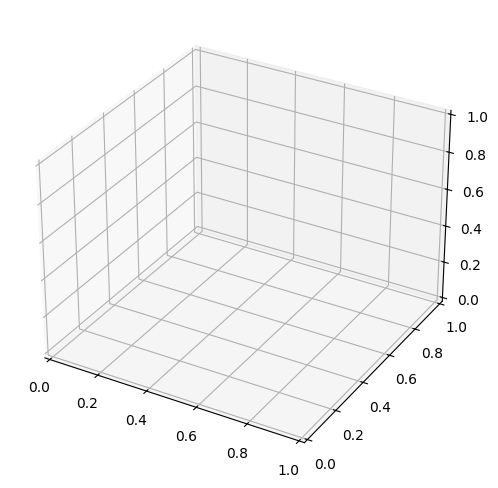

In [30]:
import numpy as np, matplotlib.pyplot as plt

# ---- Step 1: 抽出 CFR tensor → shape: (8, 8, 1024)
H = h_freq[0,:, :, 0, 0, :]   # shape: (num_rows=8, num_cols=8, num_subcarriers=1024)

# ---- Step 2: 空間 FFT（垂直方向）取 Zenith
H_vert_shifted = np.fft.fftshift(H, axes=0)
H_zenith_fft   = np.fft.fft(H_vert_shifted, axis=0)
H_zenith       = np.fft.ifftshift(H_zenith_fft, axes=0)   # shape: (8 theta, 8 azim, 1024 freq)

# ---- Step 3: 橫向平均掉 azimuth → 專注 Zenith 方向
H_zenith_avg = np.mean(H_zenith, axis=1)   # shape: (8 theta, 1024 freq)

# ---- Step 4: 頻域 IFFT → 延遲域
h_zenith_delay = np.fft.ifft(H_zenith_avg, axis=1, norm="ortho")  # shape: (8 zenith, 1024 delay)

# ---- Step 5: 建立網格資料
zeniths = np.linspace(-90, 90, 8)     # 垂直角度軸
delays  = np.arange(0, 1024*delay_resolution, delay_resolution) / 1e-9  # ns

X, Y = np.meshgrid(delays, zeniths)
Z    = 10 * np.log10(np.abs(h_zenith_delay)**2 + 1e-12)

# ---- Step 6: 畫出 3D Surface（Zenith × Delay）
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel("Delay (ns)")
ax.set_ylabel("Zenith AoA (deg)")
ax.set_zlabel("Power (dB)")
ax.set_title("Delay–Zenith CSI Surface")
ax.view_init(elev=50, azim=-40)
plt.tight_layout(); plt.show()


In [25]:
import numpy as np, pandas as pd
a, tau = paths.cir(normalize_delays=False, out_type="numpy")
print("Shape of CIR: ", a.shape) # shape (1, 1, 1, 1, 64, 1024)
print("Shape of CIR: ", tau.shape) # shape (1, 1, 1, 1, 64, 1024)
a_sel      = a  [0, 0, 0, 0, :, 0]
tau_ns     = tau[0, 0, :] / 1e-9
Zenith_deg    = np.degrees(paths.theta_r.numpy()[0,0,:])#Zenith angles of arrival [rad]
phi_deg    = np.degrees(paths.phi_r.numpy()[0,0,:]) #Azimuth angles of arrival
pow_lin    = np.abs(a_sel)**2
# ---- pull the six paths for Rx ant 0, Tx ant 0 ----


pow_lin = np.abs(a_sel)**2
pow_db  = 10*np.log10(pow_lin + 1e-30)

tbl = pd.DataFrame({
        'Path #': np.arange(len(a_sel)),
        'Delay (ns)': np.round(tau_ns,   1),
        'Azimuth (deg)': np.round(phi_deg,1),
        'Zenith (deg)': np.round(Zenith_deg,1),
        'Power (dB rel)': np.round(pow_db - pow_db.max(), 1)  # 0 dB = strongest
     })

print(tbl.to_string(index=False))
# 把每條 path 轉成 AoA + delay 對應的座標
for i in range(len(tau_ns)):
    aoa = phi_deg[i]
    delay = tau_ns[i]
    power = pow_db[i] - pow_db.max()  # 相對功率 dB

    # 找到離網格最接近的 index（optional）
    a_idx = np.argmin(np.abs(angles - aoa))
    d_idx = np.argmin(np.abs(delays - delay))

    # 用紅點標示
    ax.scatter(delay, aoa, power, color='red', s=30)


Shape of CIR:  (1, 64, 1, 1, 6, 1)
Shape of CIR:  (1, 1, 6)
 Path #  Delay (ns)  Azimuth (deg)  Zenith (deg)  Power (dB rel)
      0  166.800003     180.000000     90.000000        0.000000
      1  372.899994     180.000000    153.399994      -27.400000
      2 2269.000000     -44.799999     98.500000      -44.299999
      3 1572.599976     -83.500000     98.300003      -54.500000
      4  864.799988     160.100006    112.699997      -84.400002
      5 1657.599976     173.399994    101.599998      -56.900002


In [15]:
scene.preview(paths=paths)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …